## Brett T. Burtner
### DDS-8555 Predictive Analysis
### Dr. Sebhat Gezehey
### Linear Regressions with Abalone Dataset

In [51]:
# Import packages expected to be used
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as myMSE
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import os

In [26]:
# Read 'Abalone.csv'  ad dataframe
df = pd.read_csv('Abalone.csv')
df.head(12) # Displays df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,M,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,F,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


In [27]:
df.info() # Output shows no NAs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [28]:
df.describe() # Shows stats for numerical variables

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### Show unique values for categorical variables

In [29]:
print("Unique values for Sex variable: ",df['Sex'].unique())

Unique values for Sex variable:  ['M' 'F' 'I']


### Enumerate categorical variable

In [30]:
mapping = {'I': 2, 'F': 1, 'M': 0}
df['Sex'] = df['Sex'].replace(mapping)
df.head(12)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7
5,2,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.120,8
6,1,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.330,20
7,1,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.260,16
8,0,0.475,0.370,0.125,0.5095,0.2165,0.1125,0.165,9
9,1,0.550,0.440,0.150,0.8945,0.3145,0.1510,0.320,19


### Exploratory Data Analysis

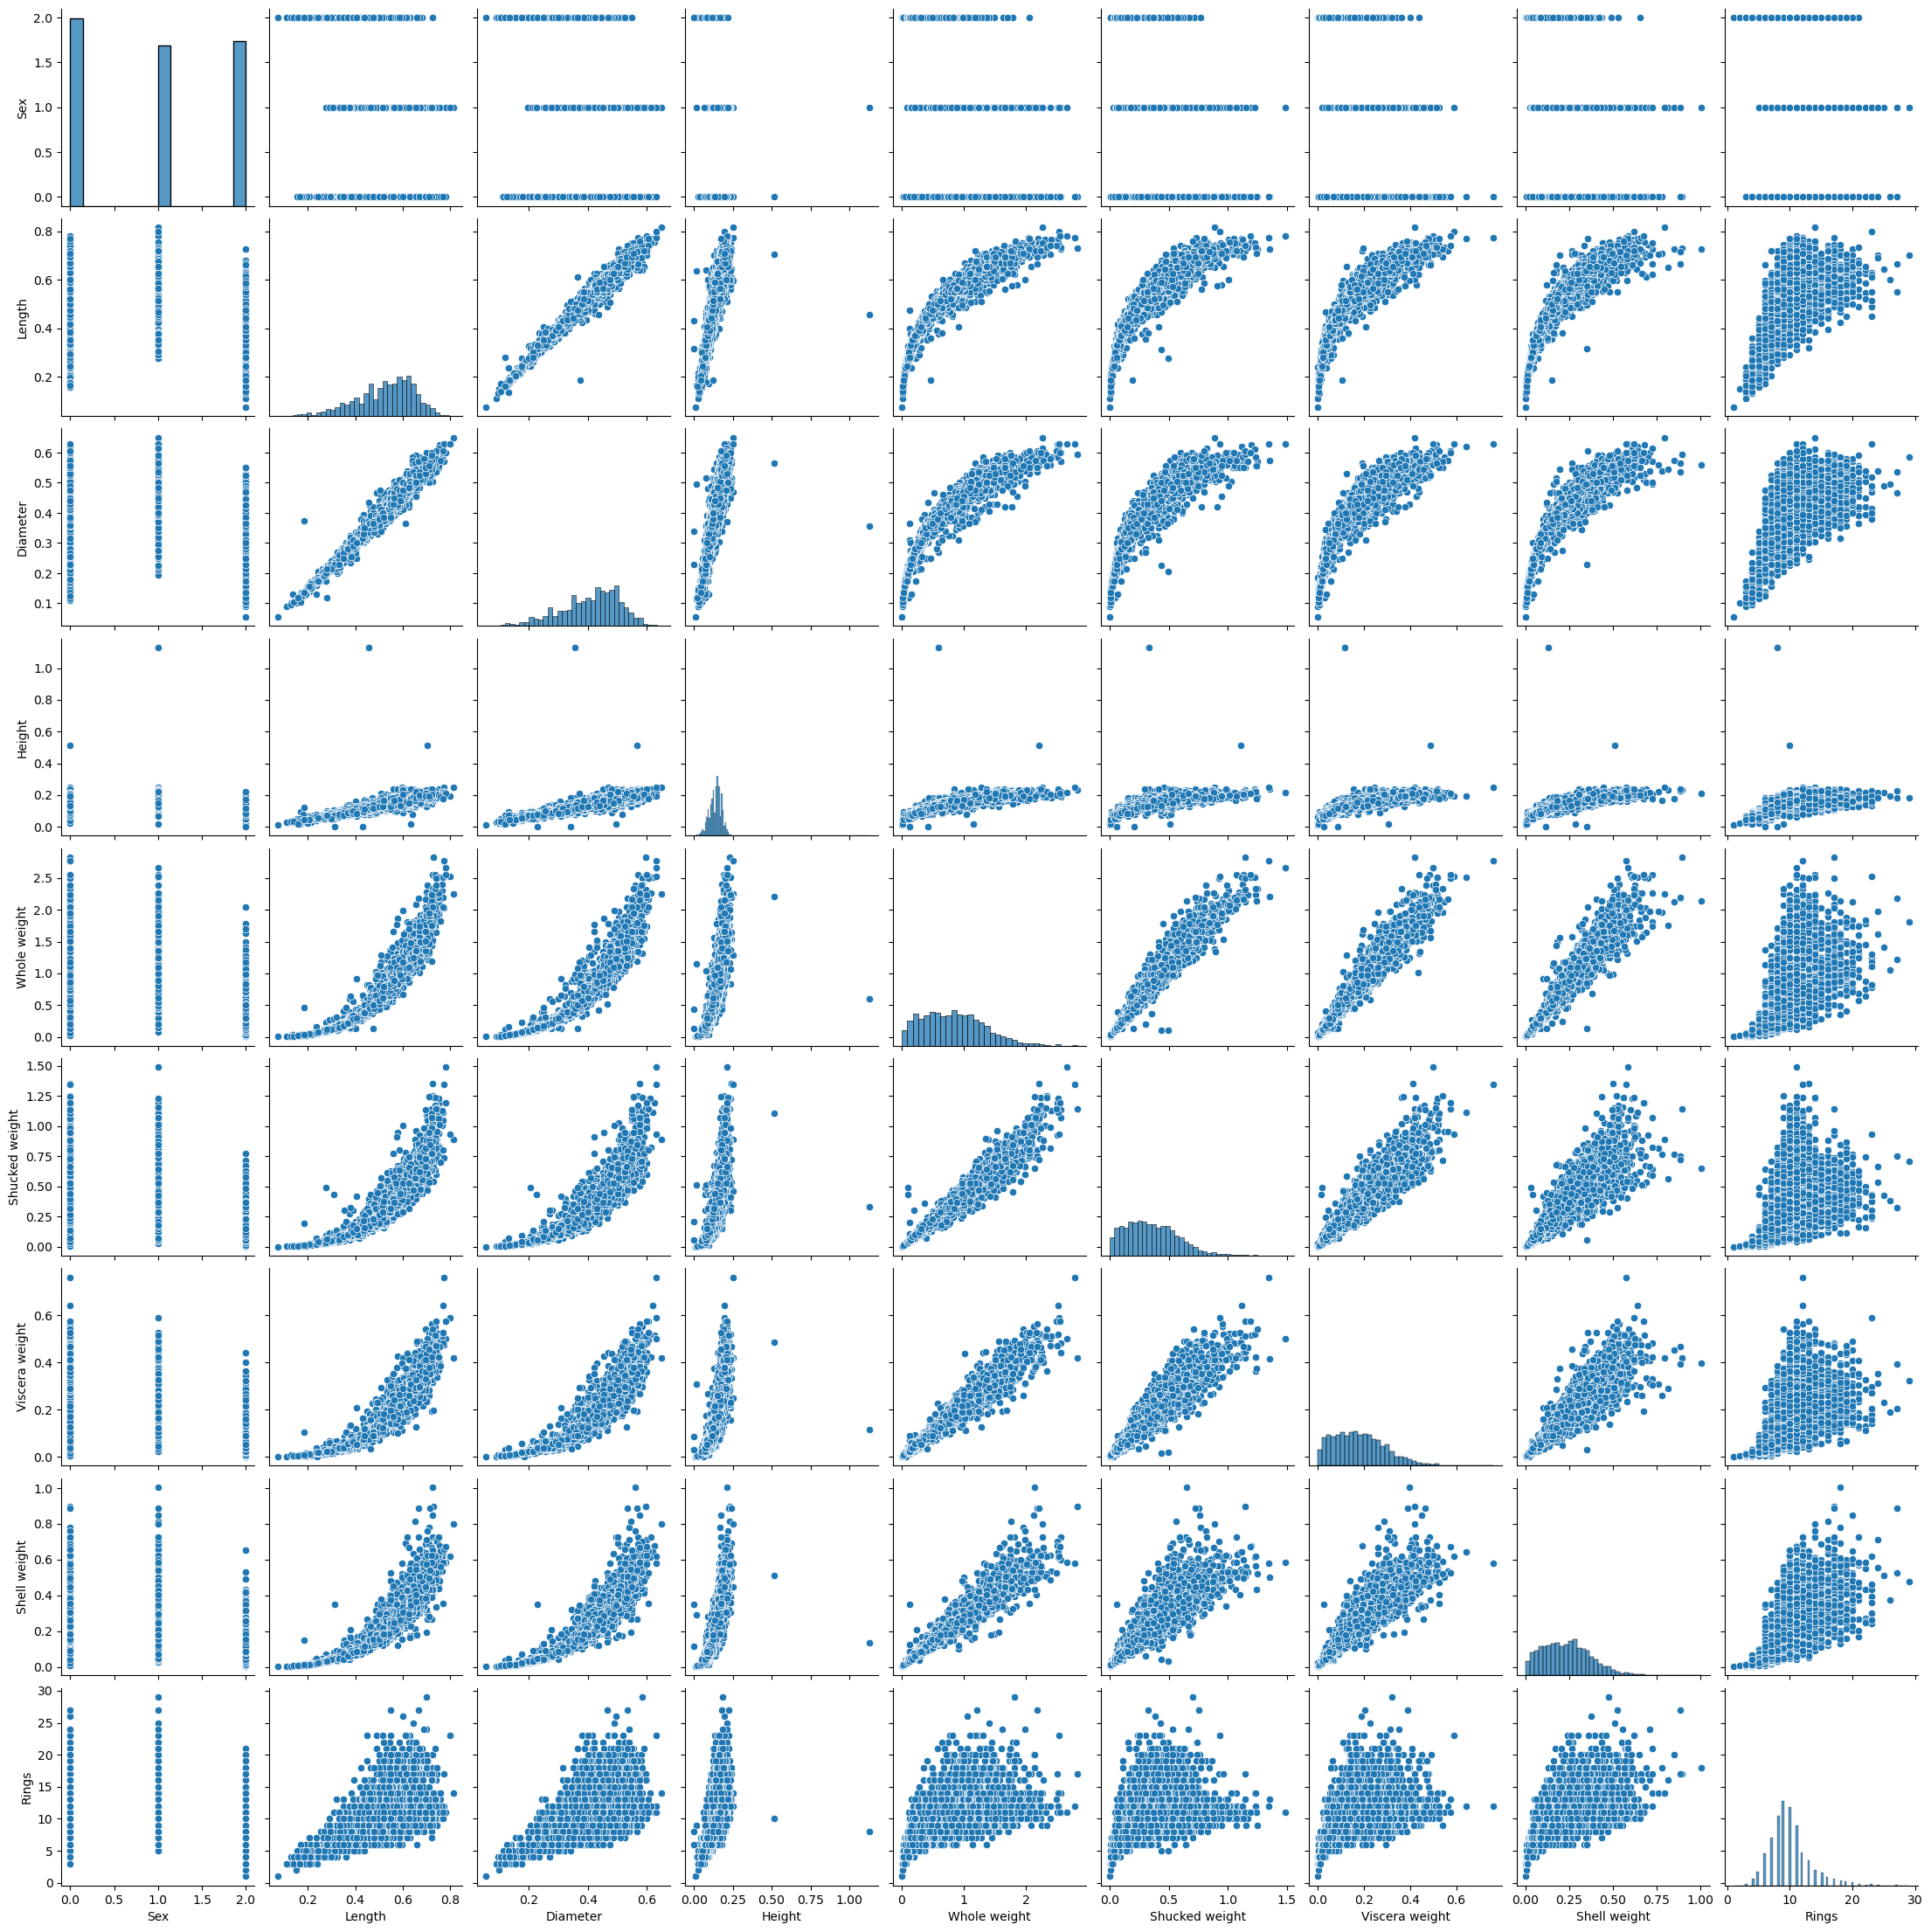

In [31]:
# Pairs plot
sns.pairplot(df)
plt.show()

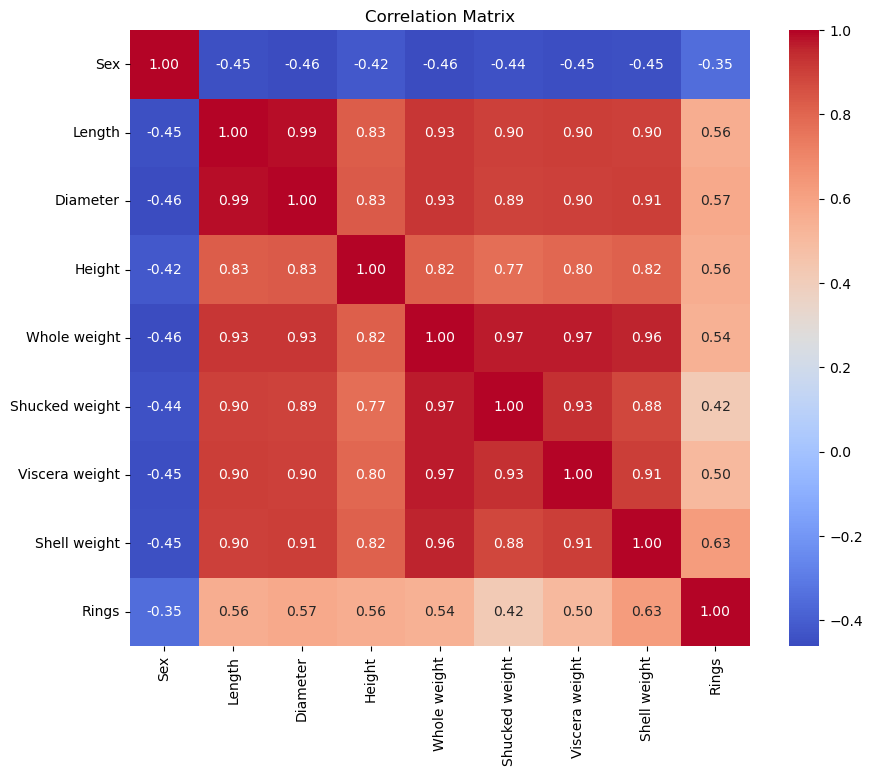

In [32]:
# Correlation matrix
correlation_matrix = df.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

This heatmap shows, interestingly enough, that sex is negatively correlated with many other values.  This is likely due to the fact that, for infant abalone, the enumerated value is zero.  Also, as could be expected all the different values of weight are highly correlated.  Height has an above average correlation with the weight variables.  

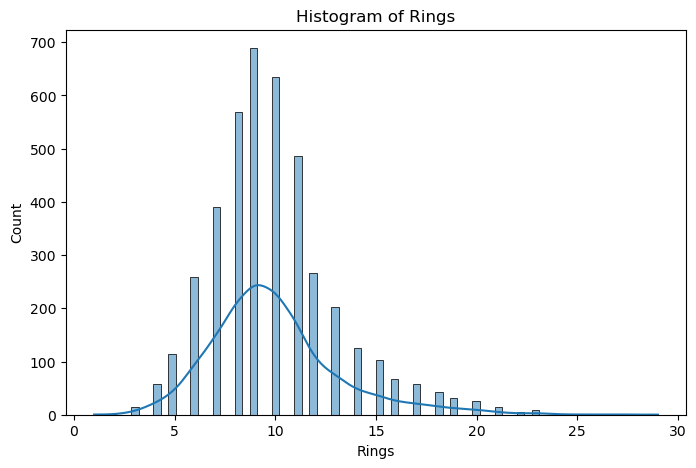

In [33]:
# Histogram of Rings
plt.figure(figsize = (8,5))
sns.histplot(df['Rings'], kde = True)
plt.title("Histogram of Rings")
plt.show()

Rings seems to fit a Gaussian distribution nicely, with the highest point at 9 rings with a count of about 680 (out of the total of over 4100) observations.

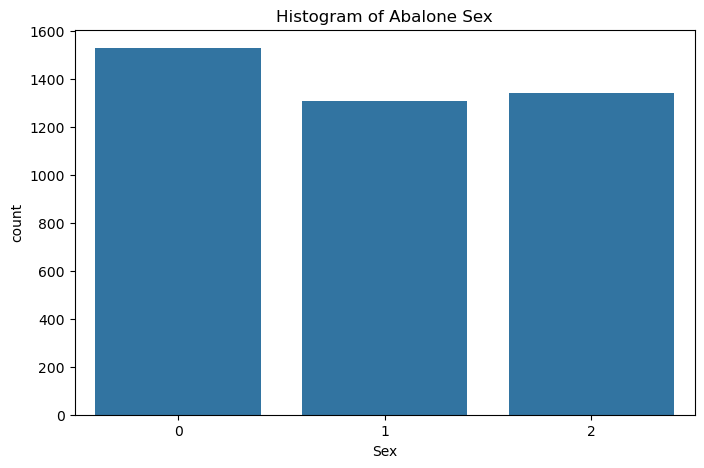

In [34]:
# Histogram of Sex variable
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', data = df)
plt.title('Histogram of Abalone Sex')
plt.show()

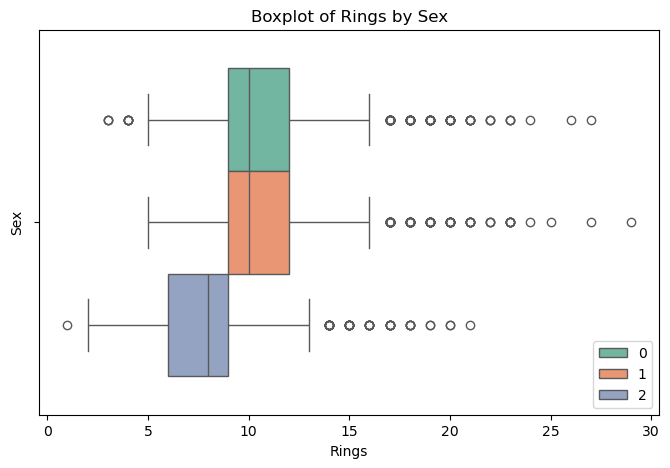

In [35]:
# Boxplots of Rings by Sex
plt.figure(figsize = (8,5))
sns.boxplot(x = 'Rings', data = df, hue = 'Sex', palette = 'Set2')
plt.legend(loc = 'lower right')
plt.title('Boxplot of Rings by Sex')
plt.xlabel("Rings")
plt.ylabel("Sex")
plt.show()

The plot above shows that infant abalone have significantly less rings than adults of both sexes, whith a median ring value of about 8 rings, compared to the adults having a median of 10 rings.

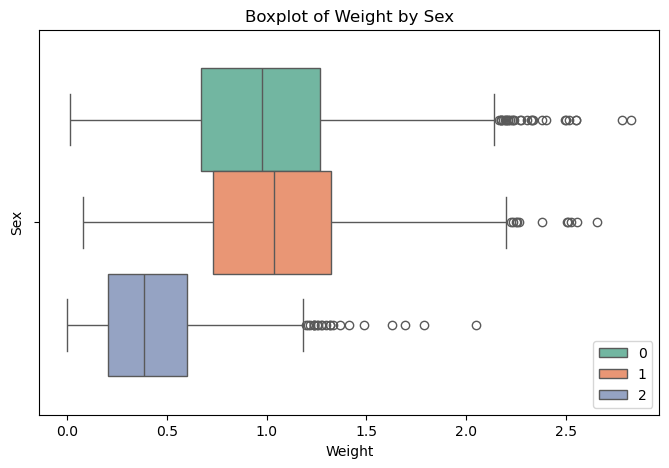

In [36]:
# Boxplots of Weight versus Sex
plt.figure(figsize = (8,5))
sns.boxplot(x = 'Whole weight', data = df, hue = 'Sex', palette = 'Set2')
plt.legend(loc = 'lower right')
plt.title('Boxplot of Weight by Sex')
plt.xlabel("Weight")
plt.ylabel("Sex")
plt.show()

This plot also shows the expected weight comparison of males, females, and infants.  Adult males have a median of ,9, whereas females have a slightly higher median of 1.0.  Infants have a significantly smaller mass of around 0.4.

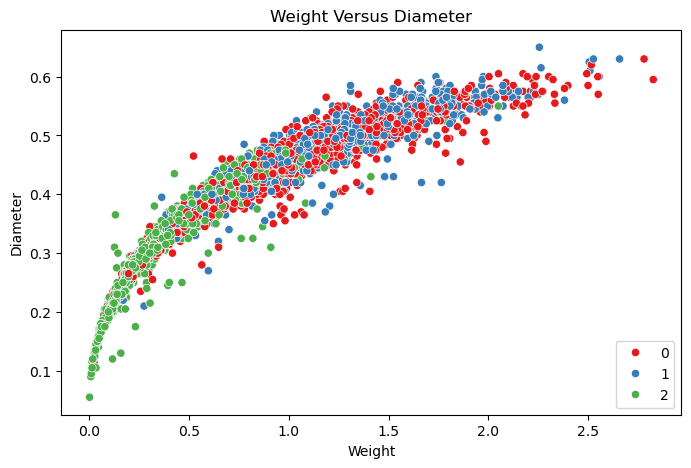

In [37]:
# Scatterplot of Height versus Weight
plt.figure(figsize = (8, 5))
sns.scatterplot(x = 'Whole weight', y = 'Diameter', hue = 'Sex', data = df, palette = 'Set1')
plt.legend(loc = 'lower right')
plt.title("Weight Versus Diameter")
plt.xlabel("Weight")
plt.ylabel("Diameter")
plt.show()

## Split data

In [38]:
# Define X and y portions of the dataset
X = df.drop(columns = ['Rings'])
y = df['Rings']

# Split the dataset 80/20
X_train, X_test, y_train, y_test = tts(X,
                                       y,
                                       train_size = 0.8,
                                       test_size = 0.2,
                                       shuffle = True,
                                       random_state = 42)

## First regression model

In [39]:
model1 = smf.ols(formula = 'Rings ~ Sex + Q("Whole weight") + Height', data = df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     723.3
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:23:47   Log-Likelihood:                -9941.8
No. Observations:                4177   AIC:                         1.989e+04
Df Residuals:                    4173   BIC:                         1.992e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.5867      0.18

In model 1, the y-intercept is 5.5867.  The Sex coefficient is negatively correlated at -0.4410.  Whole weight is positively correlated at 1.4042, and Height has a loot of weight in this model, at 25.8364

For all three independent variables in the model, I reject the null hypothesis, since p-values are all significantly less than 0.05.

## Model number 2

In [40]:
# Leaving Sex out of this second model
model2 = smf.ols(formula = 'Rings ~ Height  + Q("Whole weight")', data = df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     1038.
Date:                Fri, 20 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:24:05   Log-Likelihood:                -9973.5
No. Observations:                4177   AIC:                         1.995e+04
Df Residuals:                    4174   BIC:                         1.997e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.7940      0.16

In model 2, the y-intercept is 4.7940.  Height has a very positive correlation, making it a large contributor to model prediction.  Whole weight is positively correlated at 1.6733, but much less than Whole weight.

For model 2, I also reject the null hypothesis, since all p-values are also less than 0.05.

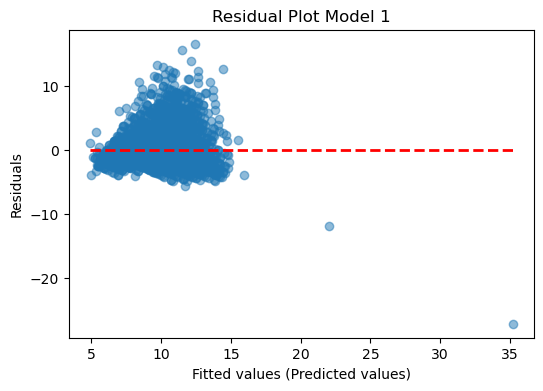

In [42]:
# Produce residuals plot for Model 1
y_pred = model1.predict(X)
residuals = y - y_pred
plt.figure(figsize = (6, 4))
plt.scatter(y_pred, residuals, alpha = 0.5)
plt.hlines(y = 0,
            xmin = min(y_pred),
            xmax = max(y_pred),
            color = 'red',
            linestyle = '--',
            lw = 2)
plt.xlabel('Fitted values (Predicted values)')
plt.ylabel('Residuals')
plt.title('Residual Plot Model 1')  
plt.show()


10.f

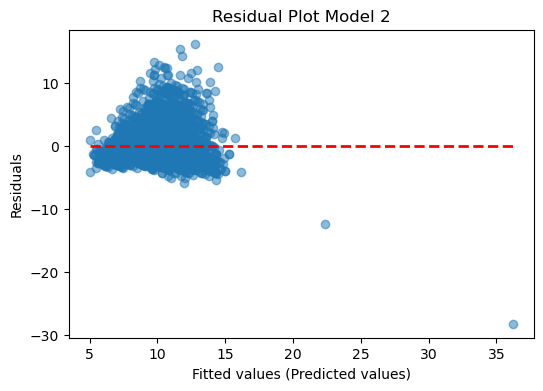

In [43]:
# Produce residuals plot for Model 2
y_pred = model2.predict(X)
residuals = y - y_pred
plt.figure(figsize = (6, 4))
plt.scatter(y_pred, residuals, alpha = 0.5)
plt.hlines(y = 0,
            xmin = min(y_pred),
            xmax = max(y_pred),
            color = 'red',
            linestyle = '--',
            lw = 2)
plt.xlabel('Fitted values (Predicted values)')
plt.ylabel('Residuals')
plt.title('Residual Plot Model 2')  
plt.show()

In [44]:
# F test for model1
f_test_results = anova_lm(model1, typ = 2)
print(f_test_results)

                         sum_sq      df           F        PR(>F)
Sex                  435.453610     1.0   63.626255  1.926696e-15
Q("Whole weight")    617.361140     1.0   90.205654  3.507965e-21
Height              1593.939558     1.0  232.898299  3.280322e-51
Residual           28559.718099  4173.0         NaN           NaN


In [45]:
# F test for model2
f_test_results = anova_lm(model2, typ = 2)
print(f_test_results)

                         sum_sq      df           F        PR(>F)
Height              1738.643003     1.0  250.286357  8.545902e-55
Q("Whole weight")    924.745125     1.0  133.121686  2.442263e-30
Residual           28995.171709  4174.0         NaN           NaN


In [49]:
# MSE comparison
y_pred1 = model1.predict(X_test)
mse1 = myMSE(y_test, y_pred1)
mse1

6.749584645126886

In [50]:
y_pred2 = model2.predict(X_test)
mse2 = myMSE(y_test, y_pred2)
mse2

6.918274221859247

Both models seem to fit the data pretty well, but model 1 appears to be a slightly better porformer at predicting number of rings.  This is due to the MSE being slightly lower for model 1.